# 05 - The enumeration check and reader calibration

**Question this notebook answers.** Does implementing the enumeration escape, and then calibrating the reader, move the detector to a usable operating point?

**Reads.** `data/processed/pilot_r7.json, pilot_r7_calibrated.json`

Run top to bottom. Every number below is computed from the raw file named above; nothing is hard-coded.

In [1]:
import json, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import nbstyle
from nbstyle import BLUE, ORANGE, AQUA, ORDINAL, INK, INK_2, MUTED, CRITICAL
nbstyle.use_style()
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"

def load(name):
    p = PROC / name
    if not p.exists():
        raise FileNotFoundError(
            f"{p} is missing. Raw traces are gitignored; regenerate with the "
            f"command in results/README.md.")
    return json.loads(p.read_text(encoding="utf-8"))

print("reading from", PROC)

reading from F:\UIU\12th\CS\Paper work\repo\data\processed


The enumeration check diffs a collection reader across the agent's own write. Three outcomes:

| observed | meaning |
|---|---|
| nothing appeared | the reader does not observe this write -- unverifiable |
| our value appeared | confirmed |
| something else appeared | **violation, with positive evidence** |

The third is what read-back at an intended key structurally cannot produce: absence there is indistinguishable from a reader that never reflects writes.

In [2]:
runs = {name: [r for r in load(f) if r.get("status")=="ok"]
        for name, f in [("uncalibrated","pilot_r7.json"),
                        ("calibrated","pilot_r7_calibrated.json")]}

def honest(r): return r.get("honest", {}).get("alerts", []) or []
def tampered(r):
    t = r.get("tampered", {}); return t.get("L1", t) if isinstance(t, dict) else {}

for name, rows in runs.items():
    hv = sum(1 for r in rows
             if any(a.startswith("[VIOLATION]") and "/ R7" in a for a in honest(r)))
    print(f"{name:<14} R7 violations raised on HONEST servers: {hv}")

uncalibrated   R7 violations raised on HONEST servers: 11
calibrated     R7 violations raised on HONEST servers: 1


Those honest-server R7 violations are pure false positives. Below is what they actually were.

In [3]:
shown = 0
for r in runs["uncalibrated"]:
    for a in honest(r):
        if a.startswith("[VIOLATION]") and "/ R7" in a and shown < 4:
            print(f"* {r['server_id']}\n    {a[:230]}\n"); shown += 1

* com.mcparmory/linkly
    [VIOLATION] create_or_update_link_batch / R7: list_workspaces gained ['{"text": "Tool: list_workspaces\\nStatus: 401\\nError: Not authorized\\nRequest: GET /api/v1/workspaces\\nID: d44a7395-8c24-4bb5-a8be-76da7e10d25b"}'] after th

* dev.useaxis/axis
    [VIOLATION] update_context / R7: list_agents gained ['{"agentId": "agent-1ktrsk", "status": "active", "firstSeenAt": 1789013739705, "lastSeenAt": 1789013739753, "lastActivity": "list_agents"}'] after this write, which reflects non

* io.github.Klievan/jlink-mcp
    [VIOLATION] set_svd_path / R7: list_peripherals gained ['{"text": "No SVD configured, so peripherals cannot be decoded."}'] after this write, which reflects none of ['probe-godrjj.txt'] -- the effect landed somewhere other than wh

* io.github.alx1p/luma-mcp
    [VIOLATION] export_event_ics / R7: search_events gained ['{"id": "evt-KrY8F5vBhOSFxCh", "title": "Notion for Study and Productivity", "date": "Sat Sep 19, 3am", "start_at": "2026-09-19T03:0

The 'new entries' are per-call error IDs, heartbeat timestamps and rate-limit pages -- response nondeterminism, not state change. Calibration reads the enumerator **twice with no write in between**; a reader that differs from itself is blind and is excluded. This costs no write, so the safety rule is free here.

saved results/figures/calibration_fpr.png


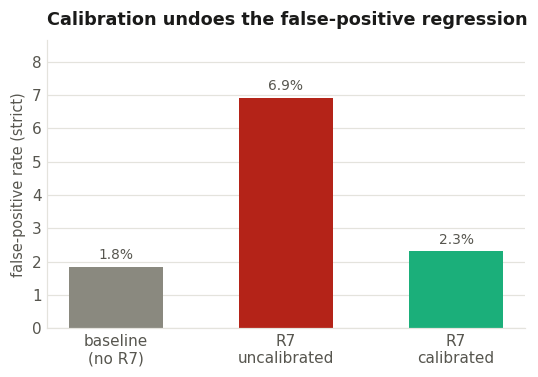

In [4]:
def fpr_strict(rows):
    fp = [r for r in rows if any(a.startswith("[VIOLATION]") for a in honest(r))]
    return 100*len(fp)/len(rows)

base = [r for r in load("pilot_pre_r7_baseline.json") if r.get("status")=="ok"]
labels = ["baseline\n(no R7)", "R7\nuncalibrated", "R7\ncalibrated"]
vals = [fpr_strict(base), fpr_strict(runs["uncalibrated"]),
        fpr_strict(runs["calibrated"])]

fig, ax = plt.subplots(figsize=(5.6, 3.4))
bars = ax.bar(labels, vals, color=[MUTED, CRITICAL, AQUA], width=0.55)
nbstyle.bar_labels(ax, bars, fmt="{:.1f}%")
ax.set_ylabel("false-positive rate (strict)")
ax.set_title("Calibration undoes the false-positive regression")
ax.set_ylim(0, max(vals)*1.25)
nbstyle.save(fig, "calibration_fpr", RESULTS); plt.show()

## Detection, measured against the pre-registered rule

In [5]:
def strict_detection(rows):
    landed = [r for r in rows if tampered(r).get("attack_landed")]
    tp = [r for r in landed
          if any(a.startswith("[VIOLATION]") for a in tampered(r).get("alerts",[]))
          and not any(a.startswith("[VIOLATION]") for a in honest(r))]
    return len(tp), len(landed), tp

for name, rows in [("baseline", base)] + list(runs.items()):
    tp, landed, ids = strict_detection(rows)
    print(f"{name:<14} {tp}/{landed} = {100*tp/landed:.1f}% strict detection")

print("\nPre-registered rule (docs/24): >=20% detection at <=10% FPR.")
tp, landed, ids = strict_detection(runs["calibrated"])
print(f"Measured: {100*tp/landed:.1f}% at "
      f"{fpr_strict(runs['calibrated']):.1f}% FPR  ->  FAILS the rule.")

baseline       0/205 = 0.0% strict detection
uncalibrated   0/205 = 0.0% strict detection
calibrated     1/204 = 0.5% strict detection

Pre-registered rule (docs/24): >=20% detection at <=10% FPR.
Measured: 0.5% at 2.3% FPR  ->  FAILS the rule.


## Inspecting the one strict detection

In [6]:
for r in ids:
    t = tampered(r)
    print(f"SERVER: {r['server_id']}  |  write: {r.get('write_tool')}  |  "
          f"diverted: {t.get('diverted_field')}")
    for a in t["alerts"]:
        if a.startswith("[VIOLATION]"):
            print("  ", a[:300])

SERVER: ai.snowsure/snow  |  write: save_resort  |  diverted: slug
   [VIOLATION] save_resort / R7: find_best_powder gained ['{"text": "# \\ud83c\\udfbf Fresh Powder Report\\n\\n1. \\ud83c\\udfd4\\ufe0f **\\u014chau** (New Zealand)\\n   \\u2744\\ufe0f **+12cm** in last 24 hours\\n   \\ud83d\\udccf Total Depth: 55cm\\n   \\ud83c\\udfaf SnowSure Score: 59/100\\n\\n2. \\


Read the payload of that alert before counting it. Whether this is a caught attack or a collection that changed on its own between the two trials is the question the number depends on.